<a href="https://colab.research.google.com/github/dzakialthalsy/health-data-visualization-PSD/blob/main/health_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Health Data Exploration - Heart Disease Dataset
## Exploratory Data Analysis (EDA) dengan Visualisasi

**Dataset**: Heart Disease UCI dari Kaggle  
**Link**: https://www.kaggle.com/datasets/mragpavank/heart-diseaseuci

### Tujuan Analisis:
1. Memahami distribusi fitur kesehatan
2. Mengidentifikasi pola dan korelasi antar variabel
3. Visualisasi hubungan antara faktor risiko dan penyakit jantung
4. Insight untuk prediksi dan pencegahan

## 1. Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Setup styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
warnings.filterwarnings('ignore')

# Konfigurasi plot
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Load Dataset

In [4]:
# Load dataset - Download dari Kaggle terlebih dahulu
df = pd.read_csv('heart.csv')

print(f'Shape Dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print('\nKolom Dataset:')
for col in df.columns:
    print(f'  - {col}')

print('\n5 Baris Pertama:')
df.head()

Shape Dataset: 303 rows x 14 columns

Kolom Dataset:
  - age
  - sex
  - cp
  - trestbps
  - chol
  - fbs
  - restecg
  - thalach
  - exang
  - oldpeak
  - slope
  - ca
  - thal
  - target

5 Baris Pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Data Quality Check

In [5]:
print('CEK KUALITAS DATA')
print('='*60)

# Missing values
missing = df.isnull().sum()
print('\nMissing Values:')
print(missing[missing > 0] if any(missing > 0) else 'Tidak ada missing values!')

# Duplicates
print(f'\nDuplikasi: {df.duplicated().sum()} rows')

# Statistik deskriptif
print('\nStatistik Deskriptif:')
df.describe().round(2)

CEK KUALITAS DATA

Missing Values:
Tidak ada missing values!

Duplikasi: 1 rows

Statistik Deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## 4. Distribusi Target Variable

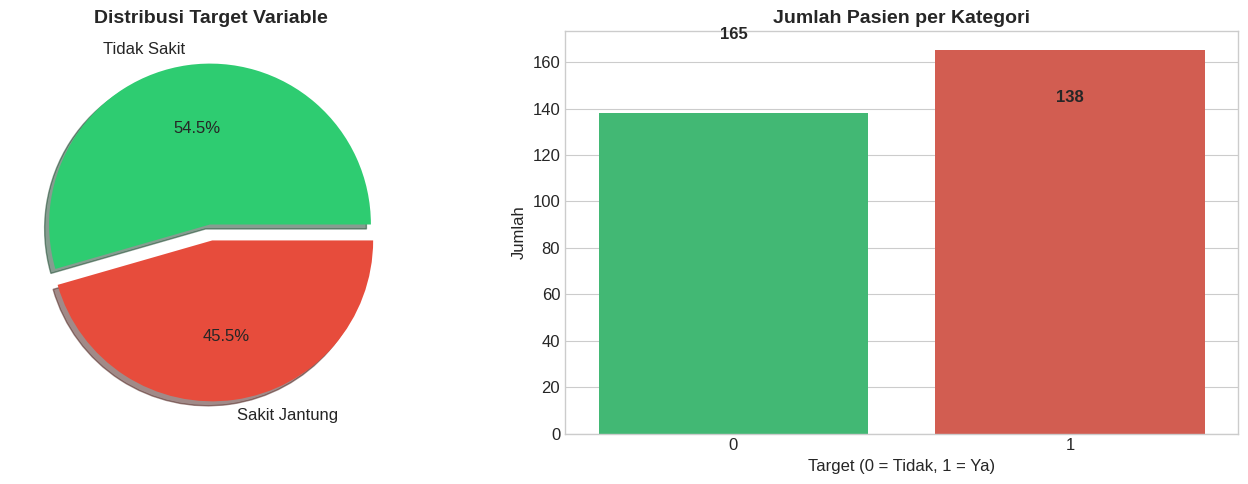


Insight: 45.5% pasien mengidap penyakit jantung


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart
target_counts = df['target'].value_counts()
axes[0].pie(target_counts.values, labels=['Tidak Sakit', 'Sakit Jantung'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            explode=(0.05, 0.05), shadow=True)
axes[0].set_title('Distribusi Target Variable', fontsize=14, fontweight='bold')

# Bar Chart
sns.barplot(x=target_counts.index, y=target_counts.values,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Jumlah Pasien per Kategori', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Target (0 = Tidak, 1 = Ya)')
axes[1].set_ylabel('Jumlah')

for i, v in enumerate(target_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nInsight: {target_counts.values[1]/len(df)*100:.1f}% pasien mengidap penyakit jantung')

## 5. Distribusi Usia dan Jenis Kelamin

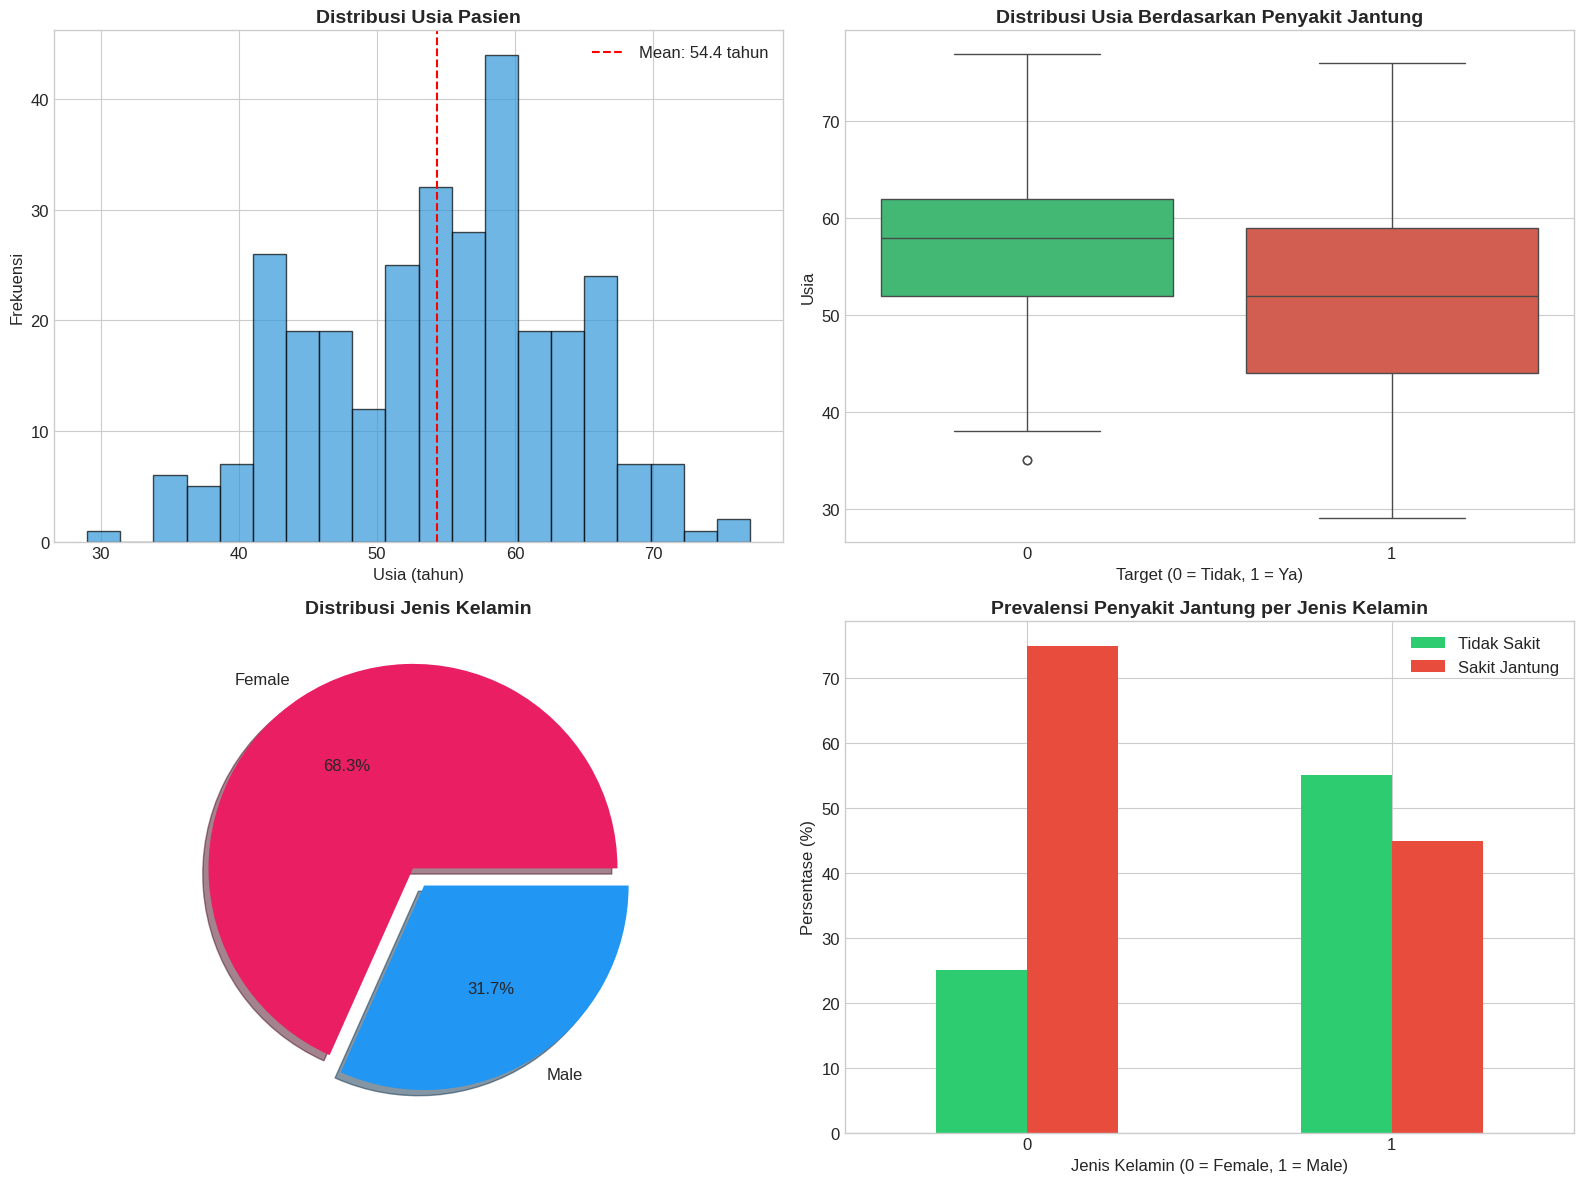


Insight: Rata-rata usia pasien adalah 54.4 tahun


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram Usia
axes[0, 0].hist(df['age'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribusi Usia Pasien', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Usia (tahun)')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df["age"].mean():.1f} tahun')
axes[0, 0].legend()

# Boxplot Usia per Target
sns.boxplot(x='target', y='age', data=df, ax=axes[0, 1],
            palette=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Distribusi Usia Berdasarkan Penyakit Jantung', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Target (0 = Tidak, 1 = Ya)')
axes[0, 1].set_ylabel('Usia')

# Jenis Kelamin - Pie Chart
sex_counts = df['sex'].value_counts()
axes[1, 0].pie(sex_counts.values, labels=['Female', 'Male'],
               autopct='%1.1f%%', colors=['#e91e63', '#2196f3'],
               explode=(0.05, 0.05), shadow=True)
axes[1, 0].set_title('Distribusi Jenis Kelamin', fontsize=14, fontweight='bold')

# Penyakit Jantung per Jenis Kelamin
sex_target = pd.crosstab(df['sex'], df['target'])
sex_target_pct = sex_target.div(sex_target.sum(axis=1), axis=0) * 100
sex_target_pct.plot(kind='bar', ax=axes[1, 1],
                    color=['#2ecc71', '#e74c3c'], stacked=False)
axes[1, 1].set_title('Prevalensi Penyakit Jantung per Jenis Kelamin', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Jenis Kelamin (0 = Female, 1 = Male)')
axes[1, 1].set_ylabel('Persentase (%)')
axes[1, 1].legend(['Tidak Sakit', 'Sakit Jantung'])
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'\nInsight: Rata-rata usia pasien adalah {df["age"].mean():.1f} tahun')

## 6. Scatter Plot: Kolesterol vs Denyut Jantung Maksimum

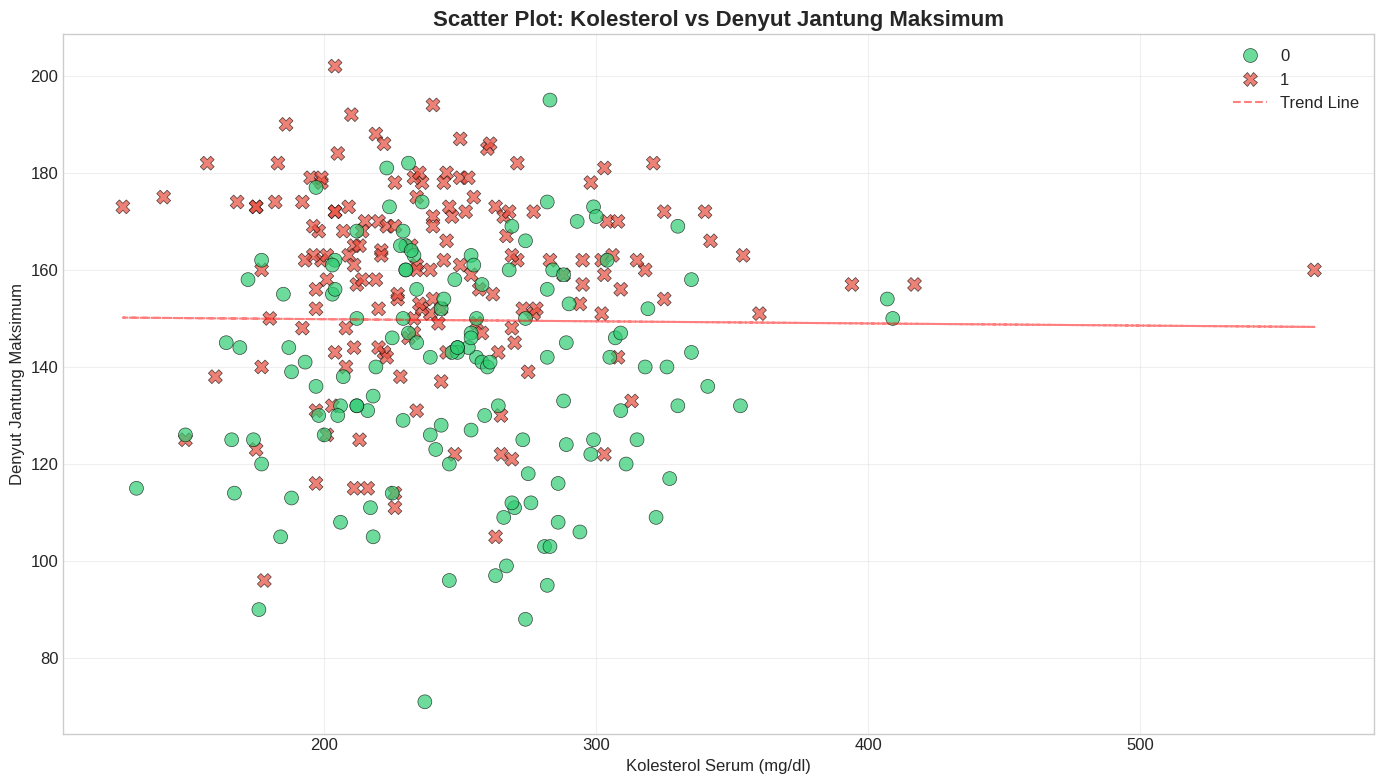


Korelasi Kolesterol vs Denyut Jantung Maksimum: -0.010


In [8]:
plt.figure(figsize=(14, 8))

# Scatter plot dengan warna berdasarkan target
sns.scatterplot(data=df, x='chol', y='thalach',
                hue='target', style='target',
                palette=['#2ecc71', '#e74c3c'],
                s=100, alpha=0.7, edgecolor='black', linewidth=0.5)

plt.title('Scatter Plot: Kolesterol vs Denyut Jantung Maksimum', fontsize=16, fontweight='bold')
plt.xlabel('Kolesterol Serum (mg/dl)', fontsize=12)
plt.ylabel('Denyut Jantung Maksimum', fontsize=12)
plt.legend(['Tidak Sakit', 'Sakit Jantung'], title='Target', loc='upper right')
plt.grid(True, alpha=0.3)

# Tambahkan trendline
z = np.polyfit(df['chol'], df['thalach'], 1)
p = np.poly1d(z)
plt.plot(df['chol'], p(df['chol']), 'r--', alpha=0.5, label='Trend Line')
plt.legend()

plt.tight_layout()
plt.show()

# Korelasi
corr = df['chol'].corr(df['thalach'])
print(f'\nKorelasi Kolesterol vs Denyut Jantung Maksimum: {corr:.3f}')

## 7. Scatter Plot: Usia vs Tekanan Darah & Kolesterol

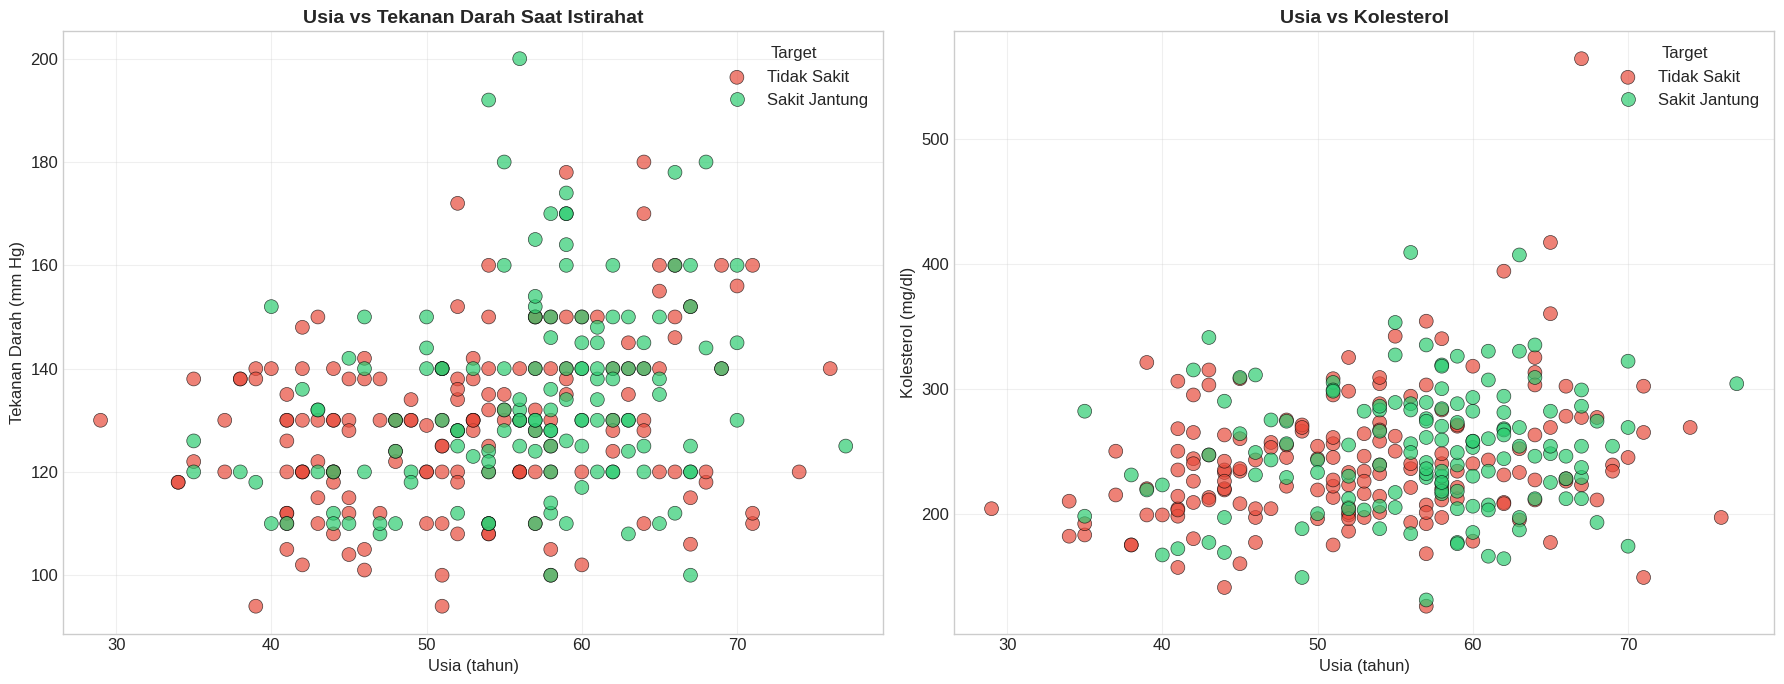

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter Plot Usia vs Tekanan Darah
sns.scatterplot(data=df, x='age', y='trestbps', hue='target',
                palette=['#2ecc71', '#e74c3c'], s=100, alpha=0.7,
                edgecolor='black', linewidth=0.5, ax=axes[0])
axes[0].set_title('Usia vs Tekanan Darah Saat Istirahat', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Tekanan Darah (mm Hg)')
axes[0].legend(['Tidak Sakit', 'Sakit Jantung'], title='Target')
axes[0].grid(True, alpha=0.3)

# Scatter Plot Usia vs Kolesterol
sns.scatterplot(data=df, x='age', y='chol', hue='target',
                palette=['#2ecc71', '#e74c3c'], s=100, alpha=0.7,
                edgecolor='black', linewidth=0.5, ax=axes[1])
axes[1].set_title('Usia vs Kolesterol', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Usia (tahun)')
axes[1].set_ylabel('Kolesterol (mg/dl)')
axes[1].legend(['Tidak Sakit', 'Sakit Jantung'], title='Target')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Chest Pain Type Analysis

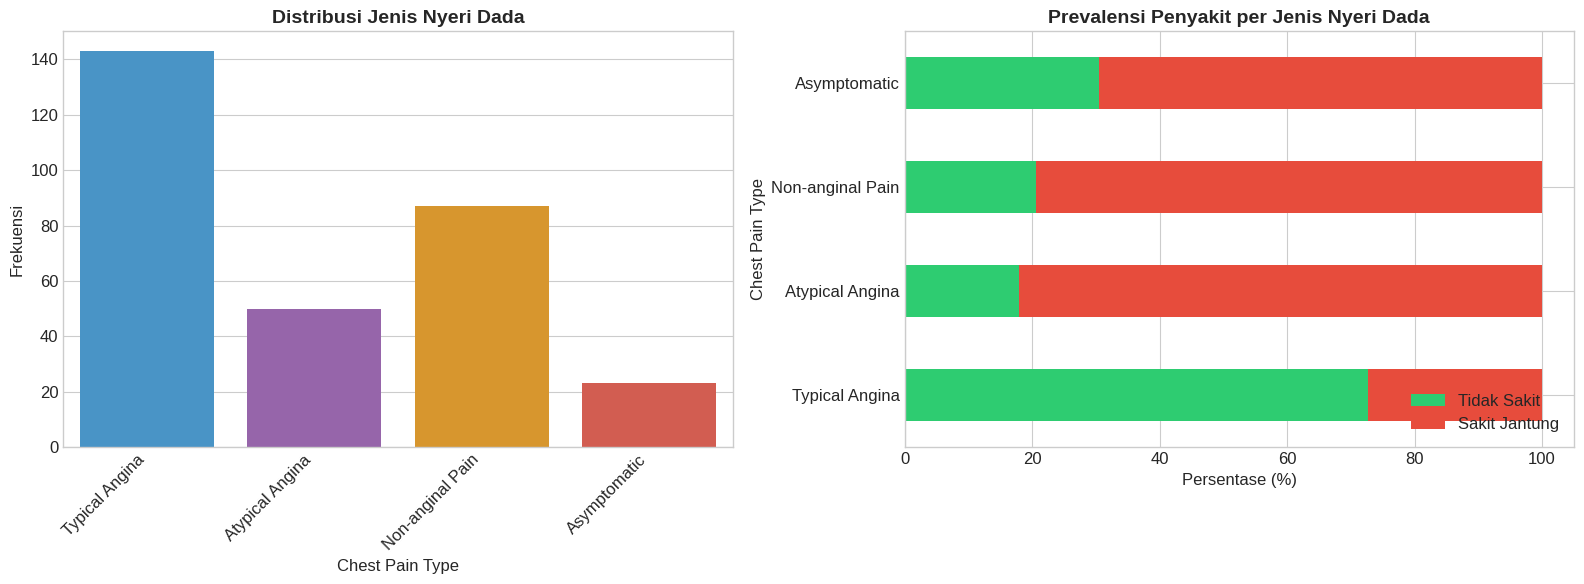

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot Chest Pain Type
cp_labels = ['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic']
cp_counts = df['cp'].value_counts().sort_index()

sns.barplot(x=cp_counts.index, y=cp_counts.values,
            palette=['#3498db', '#9b59b6', '#f39c12', '#e74c3c'], ax=axes[0])
axes[0].set_title('Distribusi Jenis Nyeri Dada', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Frekuensi')
axes[0].set_xticklabels(cp_labels, rotation=45, ha='right')

# Chest Pain vs Target
cp_target = pd.crosstab(df['cp'], df['target'])
cp_target_pct = cp_target.div(cp_target.sum(axis=1), axis=0) * 100
cp_target_pct.plot(kind='barh', ax=axes[1],
                   color=['#2ecc71', '#e74c3c'], stacked=True)
axes[1].set_title('Prevalensi Penyakit per Jenis Nyeri Dada', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Persentase (%)')
axes[1].set_ylabel('Chest Pain Type')
axes[1].set_yticklabels(cp_labels, rotation=0)
axes[1].legend(['Tidak Sakit', 'Sakit Jantung'], loc='lower right')

plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

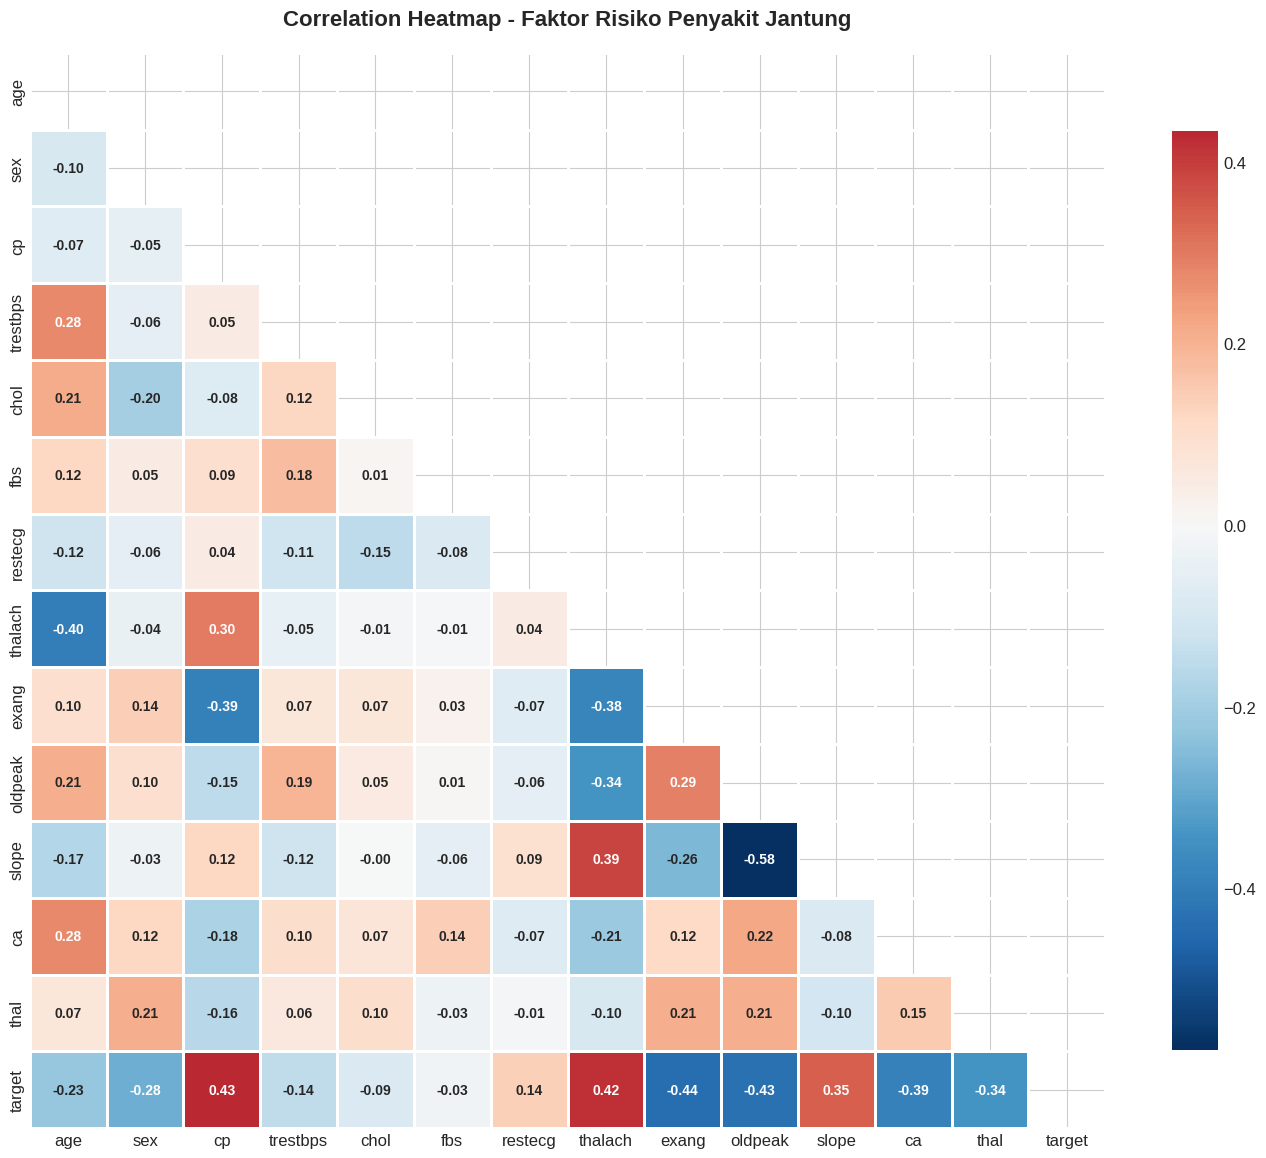


TOP 5 KORELASI DENGAN TARGET (Penyakit Jantung):
  exang        : -0.437 (abs: 0.437)
  cp           : +0.434 (abs: 0.434)
  oldpeak      : -0.431 (abs: 0.431)
  thalach      : +0.422 (abs: 0.422)
  ca           : -0.392 (abs: 0.392)


In [11]:
plt.figure(figsize=(14, 12))

# Hitung korelasi
corr_matrix = df.corr()

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=1, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10, 'weight': 'bold'})

plt.title('Correlation Heatmap - Faktor Risiko Penyakit Jantung',
          fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Top korelasi dengan target
print('\nTOP 5 KORELASI DENGAN TARGET (Penyakit Jantung):')
print('='*60)
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
for col, val in target_corr.head(5).items():
    actual_corr = corr_matrix.loc['target', col]
    print(f'  {col:12} : {actual_corr:+.3f} (abs: {val:.3f})')

## 10. Pair Plot - Subset Fitur Penting

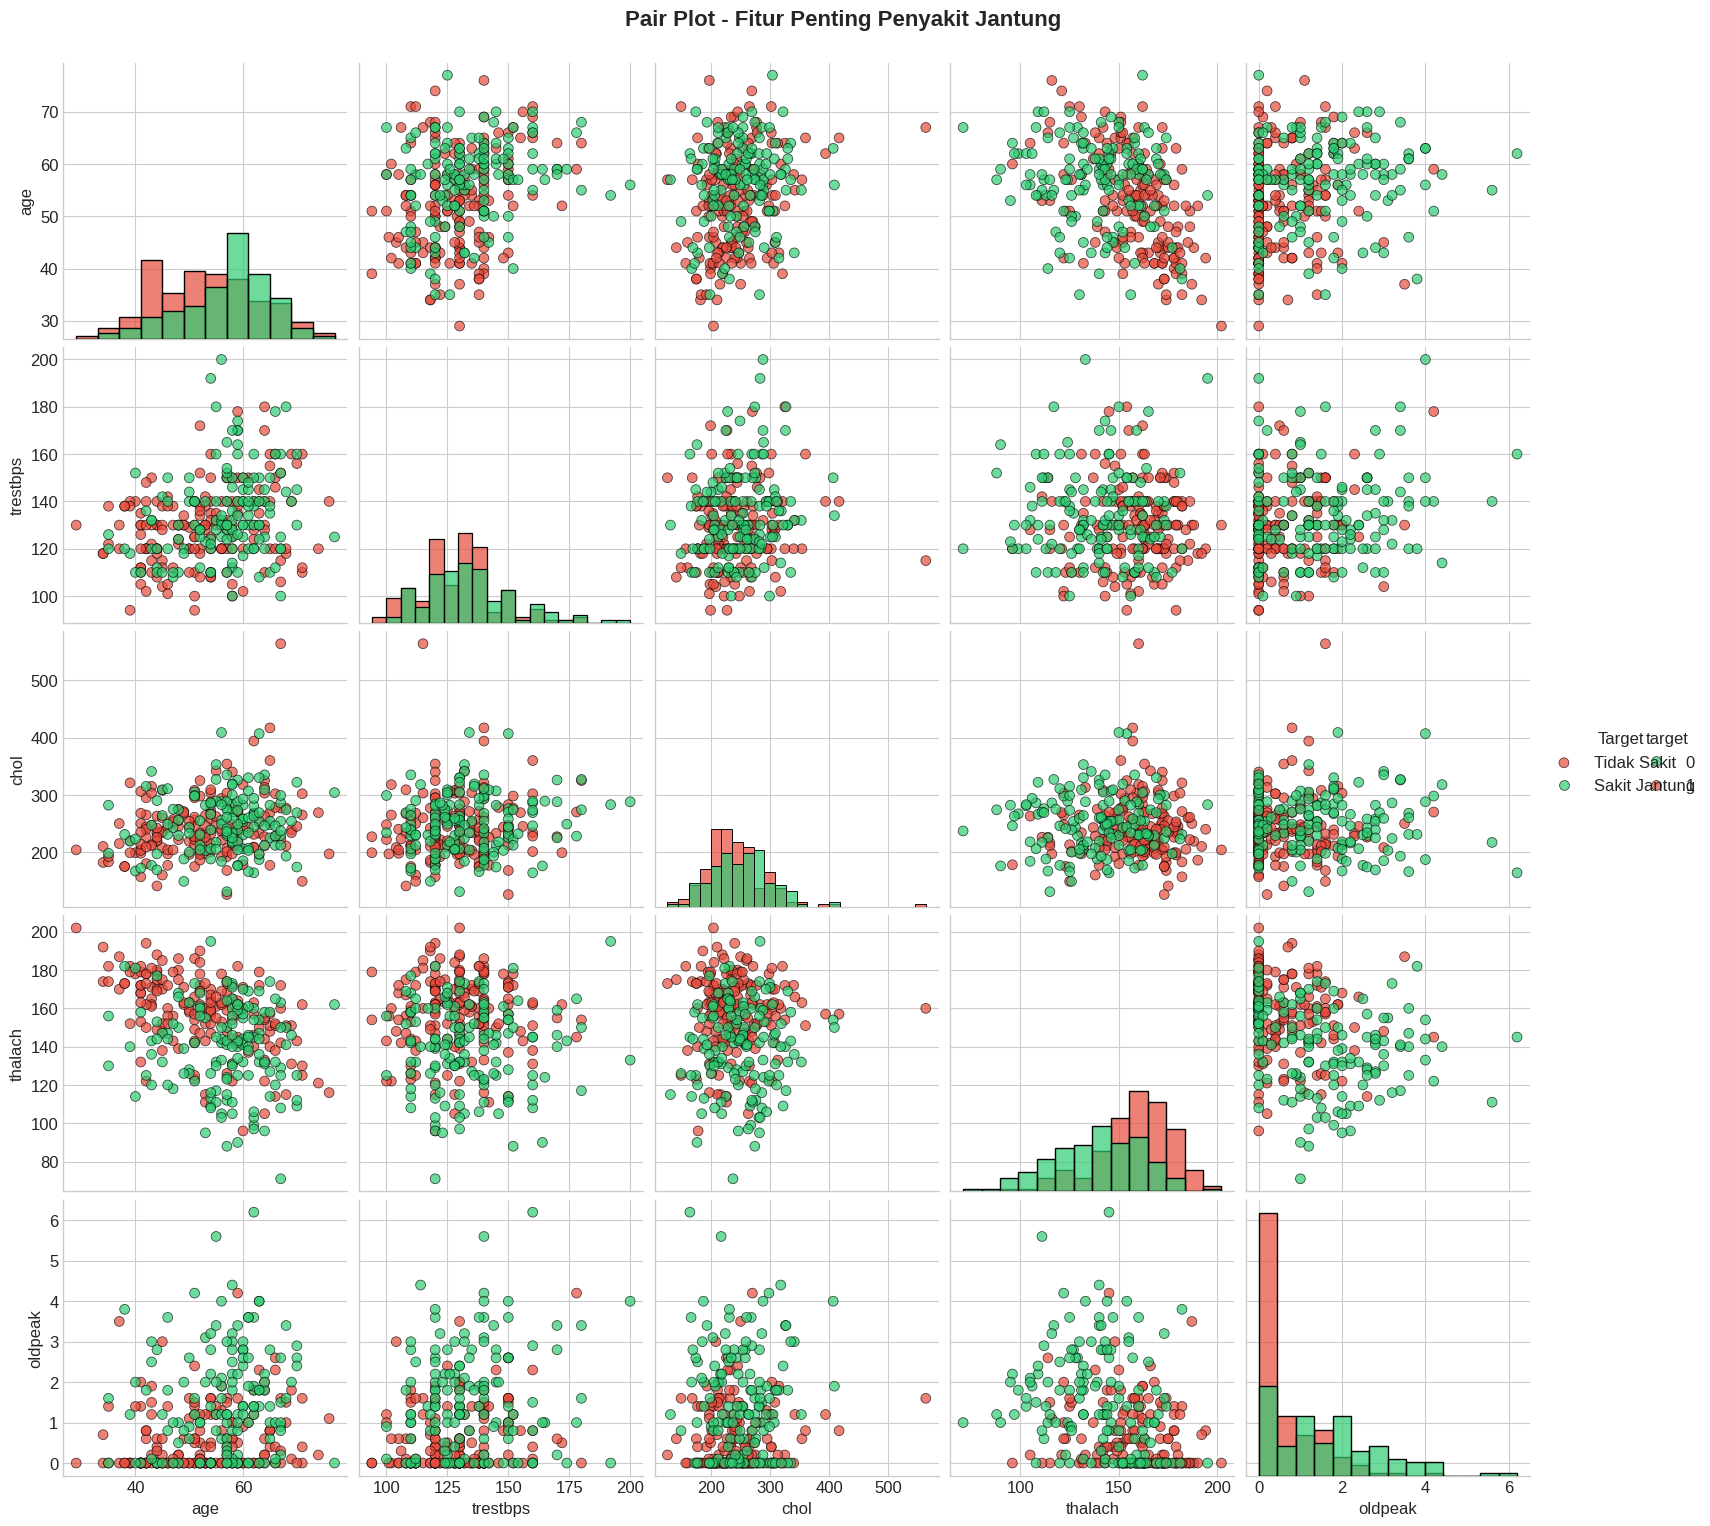

In [12]:
# Pilih subset fitur penting
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
df_subset = df[features]

pairplot = sns.pairplot(df_subset, hue='target',
                        palette=['#2ecc71', '#e74c3c'],
                        diag_kind='hist',
                        plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'black'},
                        diag_kws={'alpha': 0.7, 'edgecolor': 'black'},
                        height=3)

pairplot.fig.suptitle('Pair Plot - Fitur Penting Penyakit Jantung',
                      fontsize=16, fontweight='bold', y=1.02)
pairplot.add_legend(title='Target', labels=['Tidak Sakit', 'Sakit Jantung'])

plt.show()

## 11. Box Plot - Distribusi Fitur Numerik

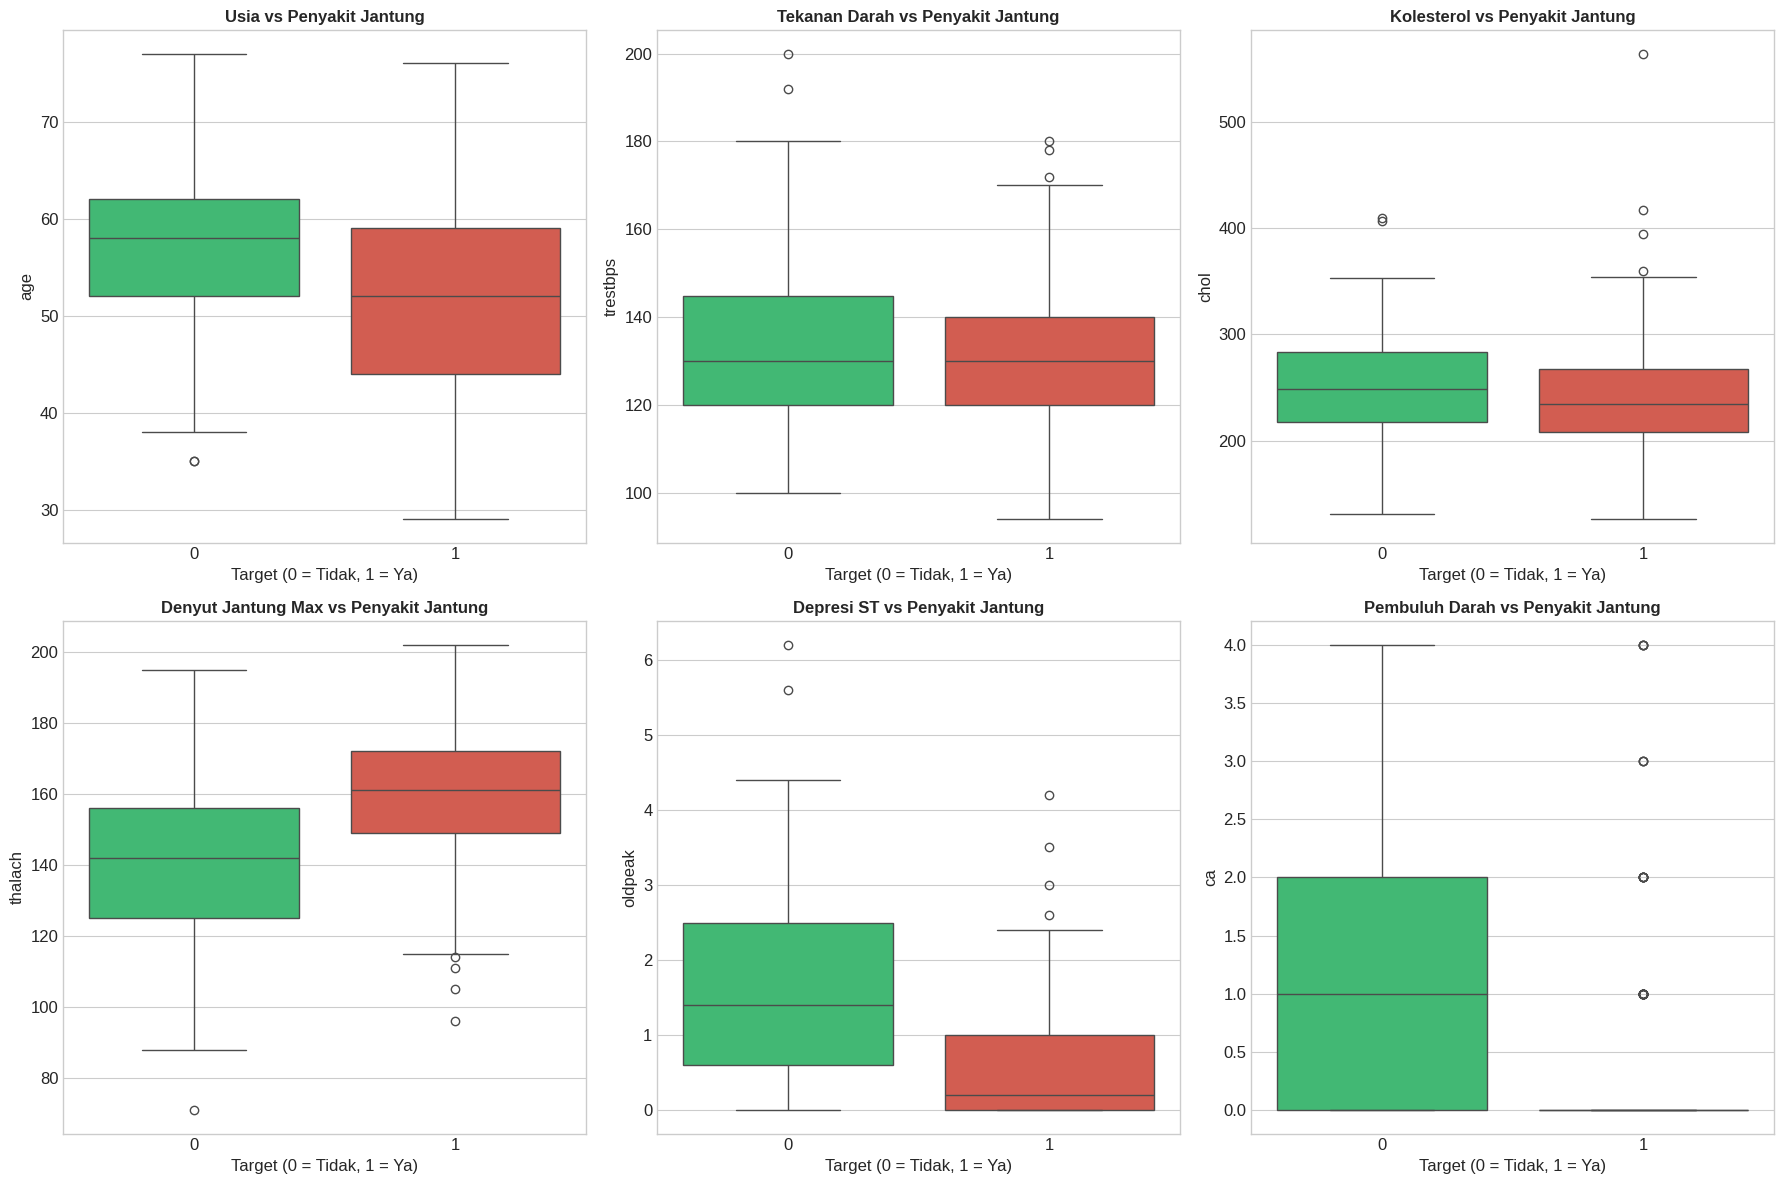

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
feature_titles = ['Usia', 'Tekanan Darah', 'Kolesterol',
                  'Denyut Jantung Max', 'Depresi ST', 'Pembuluh Darah']

for i, (feat, title) in enumerate(zip(numeric_features, feature_titles)):
    sns.boxplot(x='target', y=feat, data=df,
                ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{title} vs Penyakit Jantung', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Target (0 = Tidak, 1 = Ya)')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.show()

## 12. Feature Engineering - Risk Score

DISTRIBUSI RISK SCORE:
risk_score
0    11
1    38
2    70
3    80
4    58
5    40
6     6
Name: count, dtype: int64


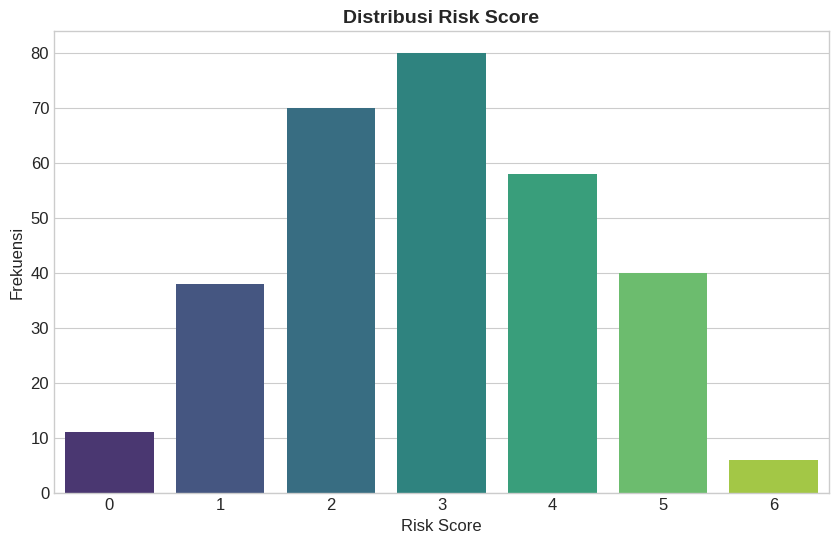

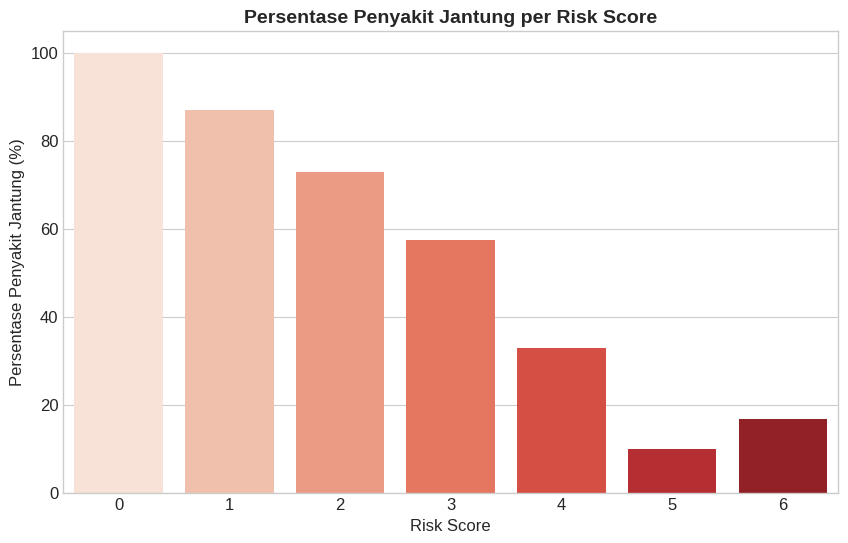


Insight: Pasien dengan risk score tinggi memiliki probabilitas penyakit jantung lebih besar


In [14]:
# Buat risk score sederhana
df['risk_score'] = 0

# Faktor risiko
df.loc[df['age'] > 50, 'risk_score'] += 1
df.loc[df['chol'] > 240, 'risk_score'] += 1
df.loc[df['trestbps'] > 140, 'risk_score'] += 1
df.loc[df['thalach'] < 150, 'risk_score'] += 1
df.loc[df['oldpeak'] > 1, 'risk_score'] += 1
df.loc[df['sex'] == 1, 'risk_score'] += 1  # Male

print('DISTRIBUSI RISK SCORE:')
print(df['risk_score'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.barplot(x=df['risk_score'].value_counts().sort_index().index,
            y=df['risk_score'].value_counts().sort_index().values,
            palette='viridis')
plt.title('Distribusi Risk Score', fontsize=14, fontweight='bold')
plt.xlabel('Risk Score')
plt.ylabel('Frekuensi')
plt.show()

# Risk Score vs Target
plt.figure(figsize=(10, 6))
risk_target = df.groupby('risk_score')['target'].mean() * 100
sns.barplot(x=risk_target.index, y=risk_target.values, palette='Reds')
plt.title('Persentase Penyakit Jantung per Risk Score', fontsize=14, fontweight='bold')
plt.xlabel('Risk Score')
plt.ylabel('Persentase Penyakit Jantung (%)')
plt.show()

print('\nInsight: Pasien dengan risk score tinggi memiliki probabilitas penyakit jantung lebih besar')

## 13. Summary & Insights

In [15]:
print('='*70)
print('RINGKASAN INSIGHT - ANALISIS PENYAKIT JANTUNG')
print('='*70)

print('\nDEMOGRAFI:')
print(f'  Total Pasien: {len(df)}')
print(f'  Rata-rata Usia: {df["age"].mean():.1f} tahun')
print(f'  Pria: {(df["sex"]==1).sum()} ({(df["sex"]==1).mean()*100:.1f}%)')
print(f'  Wanita: {(df["sex"]==0).sum()} ({(df["sex"]==0).mean()*100:.1f}%)')

print('\nPREVALENSI PENYAKIT:')
print(f'  Sakit Jantung: {df["target"].sum()} ({df["target"].mean()*100:.1f}%)')
print(f'  Tidak Sakit: {len(df) - df["target"].sum()} ({(1-df["target"].mean())*100:.1f}%)')

print('\nFAKTOR RISIKO UTAMA (berdasarkan korelasi):')
top_corr = corr_matrix['target'].drop('target').sort_values(ascending=False).head(5)
for feat, corr in top_corr.items():
    print(f'  {feat:12} : {corr:+.3f}')

print('\nREKOMENDASI:')
print('  1. Monitor tekanan darah dan kolesterol secara rutin')
print('  2. Perhatikan gejala nyeri dada, terutama tipe Typical Angina')
print('  3. Jaga denyut jantung dengan olahraga teratur')
print('  4. Screening lebih intensif untuk pria usia > 50 tahun')
print('  5. Gunakan risk score untuk identifikasi dini pasien berisiko')

print('\n' + '='*70)
print('Analisis Selesai!')
print('='*70)

RINGKASAN INSIGHT - ANALISIS PENYAKIT JANTUNG

DEMOGRAFI:
  Total Pasien: 303
  Rata-rata Usia: 54.4 tahun
  Pria: 207 (68.3%)
  Wanita: 96 (31.7%)

PREVALENSI PENYAKIT:
  Sakit Jantung: 165 (54.5%)
  Tidak Sakit: 138 (45.5%)

FAKTOR RISIKO UTAMA (berdasarkan korelasi):
  cp           : +0.434
  thalach      : +0.422
  slope        : +0.346
  restecg      : +0.137
  fbs          : -0.028

REKOMENDASI:
  1. Monitor tekanan darah dan kolesterol secara rutin
  2. Perhatikan gejala nyeri dada, terutama tipe Typical Angina
  3. Jaga denyut jantung dengan olahraga teratur
  4. Screening lebih intensif untuk pria usia > 50 tahun
  5. Gunakan risk score untuk identifikasi dini pasien berisiko

Analisis Selesai!


## 14. Advanced Visualization Dashboard

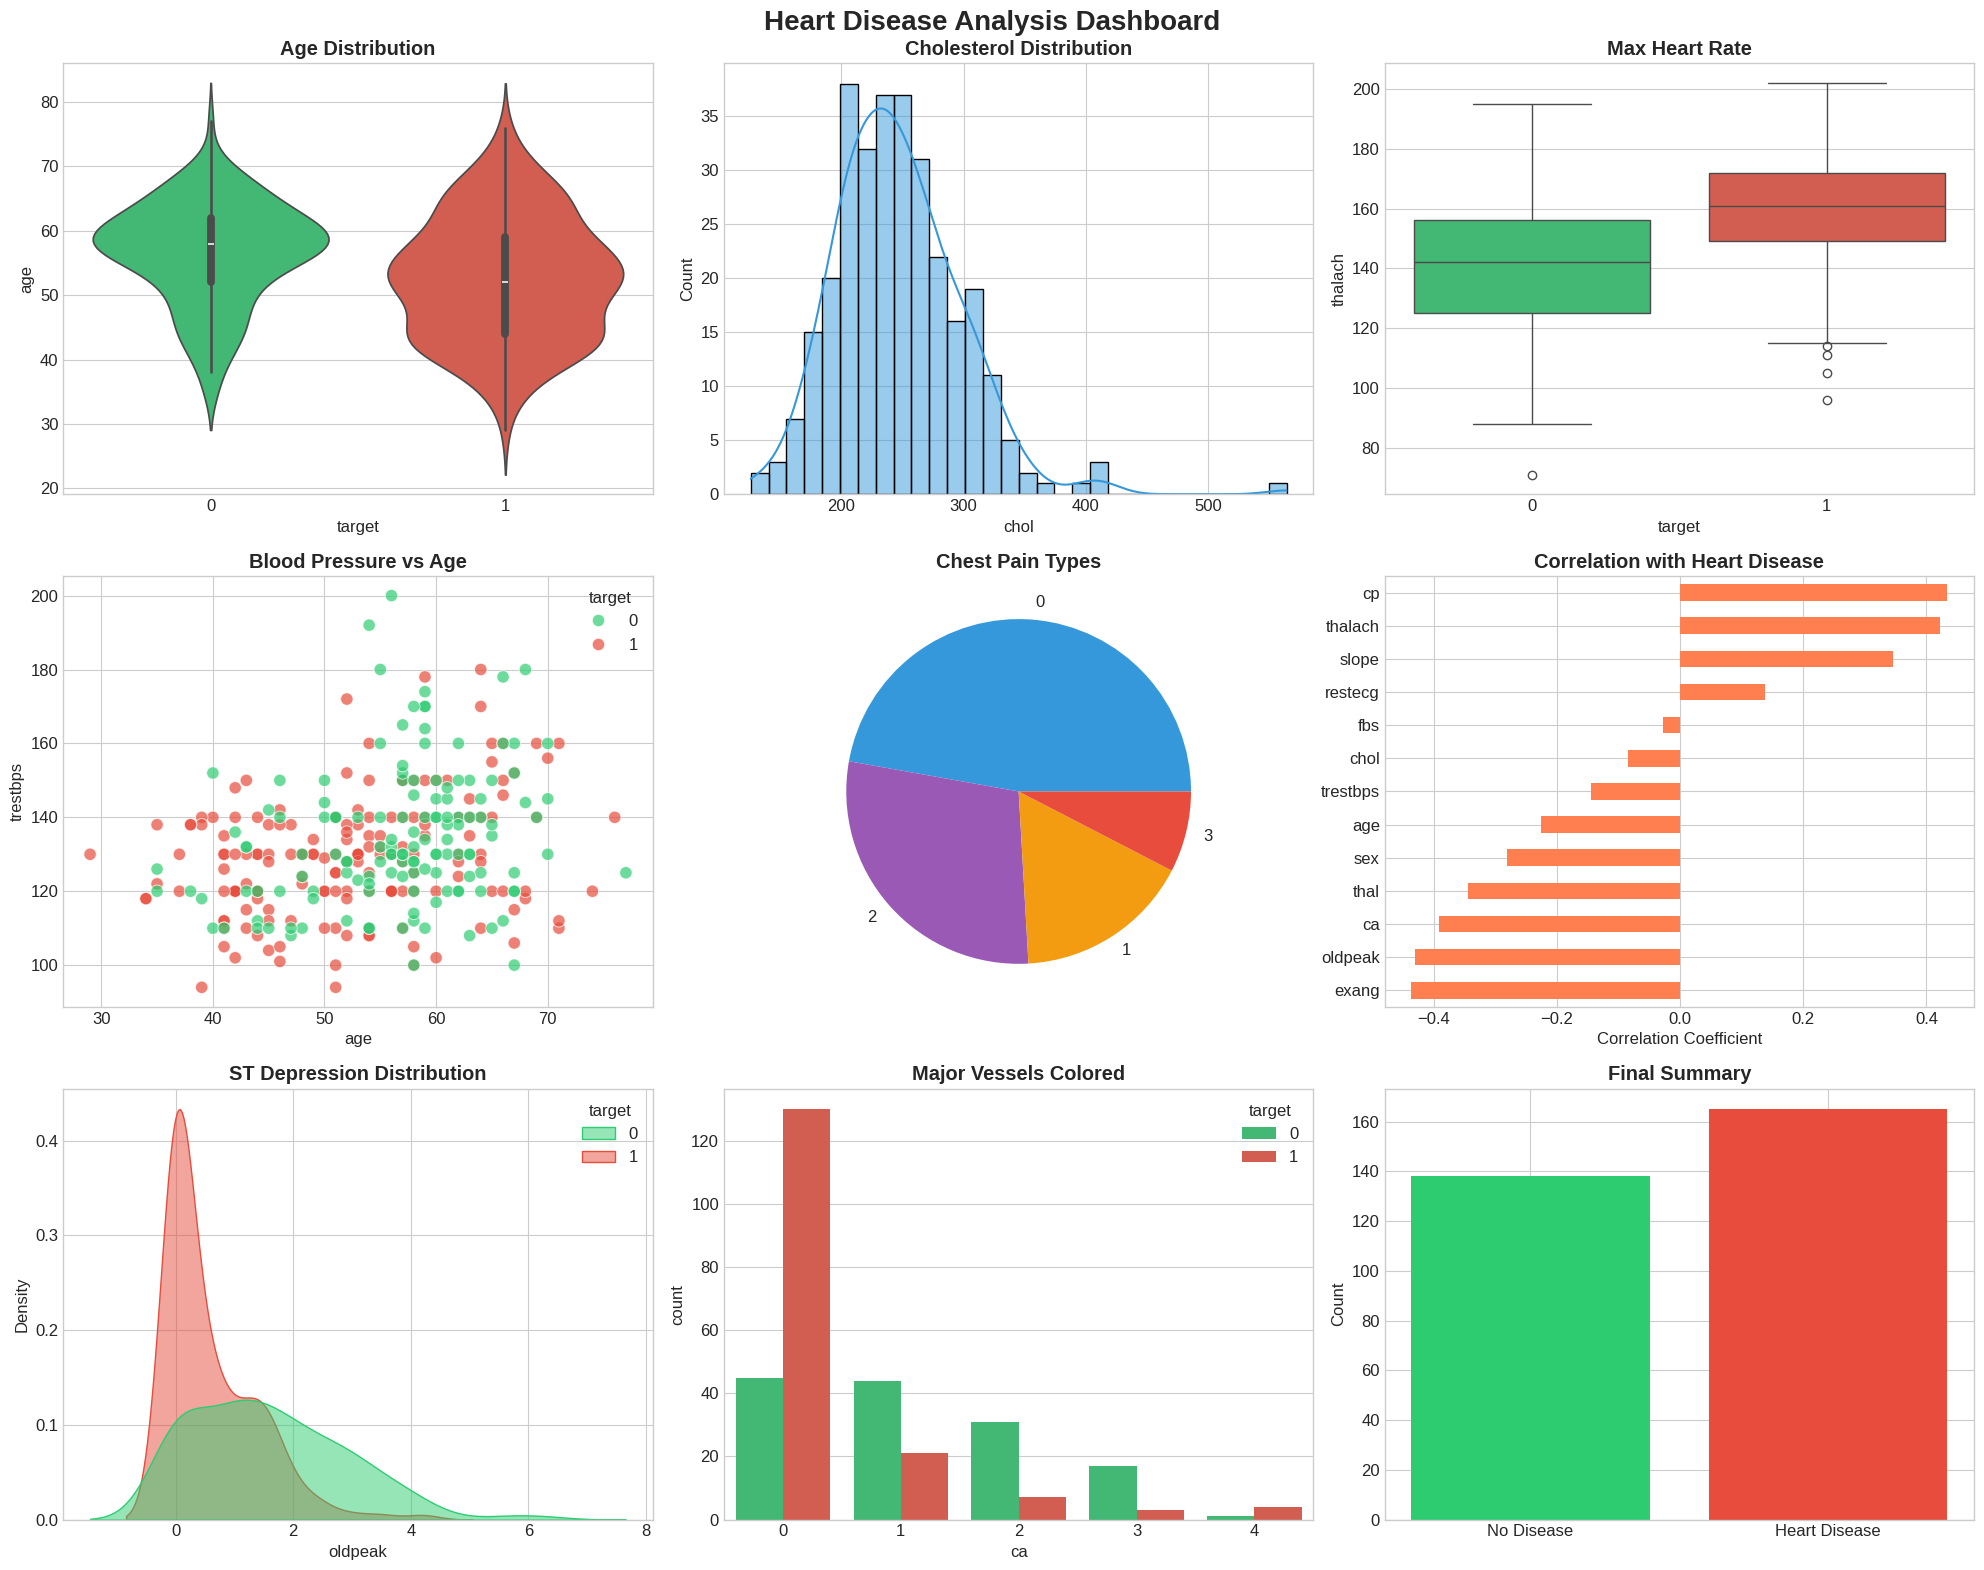


 Dashboard visualization complete!


In [16]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 16))

# 1. Age Distribution by Target
ax1 = plt.subplot(3, 3, 1)
sns.violinplot(x='target', y='age', data=df, palette=['#2ecc71', '#e74c3c'])
ax1.set_title('Age Distribution', fontweight='bold')

# 2. Cholesterol Distribution
ax2 = plt.subplot(3, 3, 2)
sns.histplot(df['chol'], bins=30, kde=True, color='#3498db')
ax2.set_title('Cholesterol Distribution', fontweight='bold')

# 3. Max Heart Rate by Target
ax3 = plt.subplot(3, 3, 3)
sns.boxplot(x='target', y='thalach', data=df, palette=['#2ecc71', '#e74c3c'])
ax3.set_title('Max Heart Rate', fontweight='bold')

# 4. Blood Pressure vs Age
ax4 = plt.subplot(3, 3, 4)
sns.scatterplot(x='age', y='trestbps', hue='target', data=df,
                palette=['#2ecc71', '#e74c3c'], alpha=0.7, s=80, ax=ax4)
ax4.set_title('Blood Pressure vs Age', fontweight='bold')

# 5. Chest Pain Type Distribution
ax5 = plt.subplot(3, 3, 5)
df['cp'].value_counts().plot(kind='pie', ax=ax5,
                             colors=['#3498db', '#9b59b6', '#f39c12', '#e74c3c'])
ax5.set_title('Chest Pain Types', fontweight='bold')
ax5.set_ylabel('')

# 6. Correlation with Target
ax6 = plt.subplot(3, 3, 6)
target_corr = corr_matrix['target'].drop('target').sort_values()
target_corr.plot(kind='barh', ax=ax6, color='coral')
ax6.set_title('Correlation with Heart Disease', fontweight='bold')
ax6.set_xlabel('Correlation Coefficient')

# 7. Oldpeak Distribution
ax7 = plt.subplot(3, 3, 7)
sns.kdeplot(data=df, x='oldpeak', hue='target', fill=True,
            palette=['#2ecc71', '#e74c3c'], alpha=0.5, ax=ax7)
ax7.set_title('ST Depression Distribution', fontweight='bold')

# 8. CA (Major Vessels) Distribution
ax8 = plt.subplot(3, 3, 8)
sns.countplot(x='ca', hue='target', data=df,
              palette=['#2ecc71', '#e74c3c'], ax=ax8)
ax8.set_title('Major Vessels Colored', fontweight='bold')

# 9. Target Summary
ax9 = plt.subplot(3, 3, 9)
ax9.bar(['No Disease', 'Heart Disease'],
        [len(df[df['target']==0]), len(df[df['target']==1])],
        color=['#2ecc71', '#e74c3c'])
ax9.set_title('Final Summary', fontweight='bold')
ax9.set_ylabel('Count')

plt.suptitle('Heart Disease Analysis Dashboard', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print('\n Dashboard visualization complete!')